In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [2]:
data = np.load("1d-m-effect.npz")

t = data["times"]
psi_m3 = data["psi_m3"]  
psi_m4 = data["psi_m4"]
psi_m5 = data["psi_m5"]

error_m3 = data["rel_l2_err_m3"]
error_m4 = data["rel_l2_err_m4"]
error_m5 = data["rel_l2_err_m5"]

In [3]:
data_k = np.load("1D-m-effect-k.npz")

k_shift = data_k["k_shift"]
freq_n8 = data_k["freq_n8"]
k_re_n3 = data_k["k_re_n3"]
k_re_n4 = data_k["k_re_n4"]
k_re_n5 = data_k["k_re_n5"]
freq_re_n3 = data_k["freq_re_n3"]
freq_re_n4 = data_k["freq_re_n4"]
freq_re_n5 = data_k["freq_re_n5"]

In [4]:
data = np.load("1d-differmethod-effect.npz")

t = data["times"]
ssfm = data["psi_ssfm"]  

In [ ]:
n = 8                                                 
N = 2**n                                               
x_max = 10
x = np.linspace(-x_max, x_max, N)

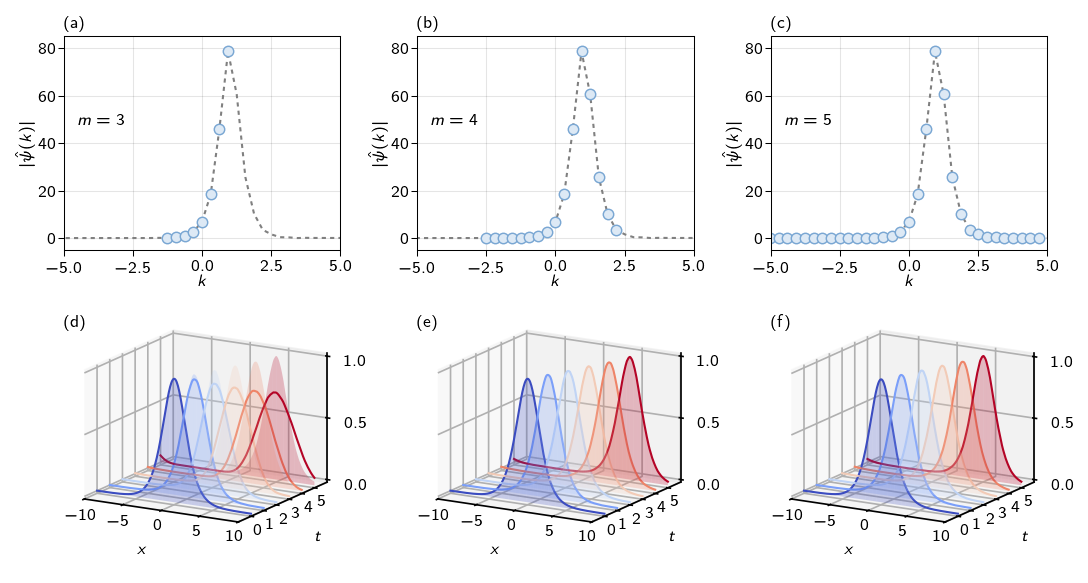

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fontsize = 8
dt = 0.01
t_values = [0, 1, 2, 3, 4, 5]


width = 17.9 / 2.54
height = width * 0.57  
cmap = plt.get_cmap('coolwarm')
colors = [cmap(i / (len(t_values) - 1)) for i in range(len(t_values))]

fig = plt.figure(figsize=(width, height))
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[0.75, 1.0], 
    hspace=0.15,
    wspace=0.28
)


axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]


axes_bottom = [fig.add_subplot(gs[1, i], projection='3d') for i in range(3)]



def plot_top_panel(
    ax,
    k_shift,
    freq_ref,
    k_re,
    freq_re,
    inner_text=None,         
    title=None,               
    title2=None,             
    label_x=0.00,
    label_y=0.96,
    label_fontsize=8,
    label2_x=0.72,
    label2_y=0.96,
    label2_fontsize=8,
    inner_text_x=-4.5,
    inner_text_y=47.5,
    xlim=(-5, 5),
    ylim=(-5, 85),
    xlabel_pad=0,
    ylabel_pad=1.5,
    tick_pad_x=1.5,
    tick_pad_y=1.0,
):
    ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)


    ax.plot(
        k_shift, freq_ref,
        linewidth=1,
        linestyle='--',
        dashes=(2, 2),
        color='gray'
    )


    ax.plot(
        k_re, freq_re,
        linestyle='none',
        marker='o',
        markersize=5,
        markerfacecolor='#DDE9F5',
        markeredgecolor='#7AA7D3',
        markeredgewidth=0.7
    )

    if inner_text is not None:
        ax.text(inner_text_x, inner_text_y, inner_text, fontsize=fontsize)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r'$k$', labelpad=xlabel_pad, size=fontsize)
    ax.set_ylabel(r'$|\hat{\psi}(k)|$', labelpad=ylabel_pad, size=fontsize)
    ax.set_xticks(np.linspace(-5, 5, 5))
    ax.set_yticks(np.linspace(0.0, 80, 5))

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.tick_params(
        axis='x', which='major',
        direction='out', top=False, right=False,
        length=3, width=0.5, pad=tick_pad_x, labelsize=fontsize
    )
    ax.tick_params(
        axis='y', which='major',
        direction='out', top=False, right=False,
        length=3, width=0.5, pad=tick_pad_y, labelsize=fontsize
    )
    ax.tick_params(
        which='minor',
        direction='out', top=False, right=False,
        length=1.5, width=0.5
    )


    if title is not None:
        ax.text(
            label_x, label_y, title,
            transform=ax.transAxes,
            fontsize=label_fontsize,
            va='top', ha='left'
        )


    if title2 is not None:
        ax.text(
            label2_x, label2_y, title2,
            transform=ax.transAxes,
            fontsize=label2_fontsize,
            va='top', ha='left'
        )



def plot_bottom_panel(
    ax,
    x,
    psi_line,
    psi_ref,
    title=None,
    show_legend=False,

    label_x=0.00,
    label_y=0.92,
    label_fontsize=8,

    title2=None,
    label2_x=0.72,
    label2_y=0.92,
    label2_fontsize=8,

    tick_pad_x=-5,
    tick_pad_y=-5,
    tick_pad_z=-3,

    xlabel_pad=-5,
    ylabel_pad=-5,
):
    x = np.asarray(x)

    for j, t in enumerate(t_values):
        idx = int(round(t / dt))

        line_curve = np.asarray(psi_line[idx])
        ref_curve = np.asarray(psi_ref[idx])

        if np.iscomplexobj(line_curve):
            line_curve = np.abs(line_curve)
        if np.iscomplexobj(ref_curve):
            ref_curve = np.abs(ref_curve)

   
        t_array = np.full(x.shape, t, dtype=float)
        ax.plot(
            x, t_array, line_curve,
            linewidth=1,
            color=colors[j],
            label=f"t={t}" if show_legend else None
        )


        X = np.tile(x, (2, 1))
        Y = np.full((2, x.size), t, dtype=float)
        Z = np.vstack([ref_curve, np.zeros_like(ref_curve)])

        ax.plot_surface(
            X, Y, Z,
            color=colors[j],
            alpha=0.25,
            linewidth=0,
            shade=False
        )

    ax.set_xlim(-10, 10)
    ax.set_ylim(-1, 6)
    ax.set_yticks(np.linspace(0, 5, 6))
    ax.set_zticks(np.linspace(0, 1, 3))

    ax.invert_xaxis()
    ax.invert_yaxis()

    ax.set_xlabel(r'$x$', labelpad=xlabel_pad, size=fontsize)
    ax.set_ylabel(r'$t$', labelpad=ylabel_pad, size=fontsize)

    ax.tick_params(axis='x', pad=tick_pad_x, labelsize=fontsize)
    ax.tick_params(axis='y', pad=tick_pad_y, labelsize=fontsize)
    ax.tick_params(axis='z', pad=tick_pad_z, labelsize=fontsize)

    ax.set_proj_type('ortho')
    ax.view_init(elev=15, azim=120)
    ax.grid(True)

    if title is not None:
        ax.text2D(
            label_x, label_y, title,
            transform=ax.transAxes,
            fontsize=label_fontsize,
            va='top', ha='left'
        )

    if title2 is not None:
        ax.text2D(
            label2_x, label2_y, title2,
            transform=ax.transAxes,
            fontsize=label2_fontsize,
            va='top', ha='left'
        )

    if show_legend:
        ax.legend(frameon=False, fontsize=fontsize)



plot_top_panel(
    axes_top[0],
    k_shift=k_shift,
    freq_ref=freq_n8,
    k_re=k_re_n3,
    freq_re=freq_re_n3,
    inner_text=r'$m=3$',
    title='(a)',
    #xlim=(np.min(k_shift), np.max(k_shift)),
    #title2=r'$m=3$',
    label_x=0.0, label_y=1.1,
    label2_x=0.72, label2_y=0.96
)

plot_top_panel(
    axes_top[1],
    k_shift=k_shift,
    freq_ref=freq_n8,
    k_re=k_re_n4,
    freq_re=freq_re_n4,
    inner_text=r'$m=4$',
    title='(b)',
    #title2=r'$m=4$',
    label_x=0.0, label_y=1.1,
    label2_x=0.72, label2_y=0.96
)

plot_top_panel(
    axes_top[2],
    k_shift=k_shift,
    freq_ref=freq_n8,
    k_re=k_re_n5,
    freq_re=freq_re_n5,
    inner_text=r'$m=5$',
    title='(c)',
    #title2=r'$n=11$',
    label_x=0.0, label_y=1.1,
    label2_x=0.68, label2_y=0.5
)



plot_bottom_panel(
    axes_bottom[0], x, psi_m3, ssfm,
    title='(d)',
    #title2=r'$n=5$',
    label_x=0.00, label_y=0.92,
    #label2_x=0.72, label2_y=0.92,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=0,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)

plot_bottom_panel(
    axes_bottom[1], x, psi_m4, ssfm,
    title='(e)',
    #title2=r'$n=8$',
    label_x=0.00, label_y=0.92,
    #label2_x=0.72, label2_y=0.92,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=0,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)

plot_bottom_panel(
    axes_bottom[2], x, psi_m5, ssfm,
    title='(f)',
    #title2=r'$n=11$',
    label_x=0.00, label_y=0.92,
    #label2_x=0.68, label2_y=0.92,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=0,    
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)


plt.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.08,
    top=0.97,
    wspace=0.28,
    hspace=0.18
)

plt.savefig("1D_m_effect.svg", dpi=300,bbox_inches="tight", pad_inches=0.02)
plt.savefig("1D_m_effect.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
# plt.show()